# Comparing model characterization approaches (attractor vs. simulation)

In this notebook, we compare two model characterization approaches: the gold-standard attractor calculation approach (implemented with the `boolsim` package) and the model simulation approach (via MaBoSS). We evaluate both methods using ARI and simulation time.

Before running this notebook, execute the scripts in this folder sequentially:

1) `01_calculate_attractor.py`: Calculate the set of attractors for each model.

2) `02_simulate_models.py`: Perform MaBoSS simulations for each model in the ensemble.

3) `03_calculate_ARI.py`: Perform model clustering based on MaBoSS simulation results and compare it with model groups based on attractor calculations. The comparison result is reported as ARI.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

os.chdir('../../')


## Load and preprocess ARI scores

This section loads trajectory-based ARI results, fills missing values, keeps the maximum ARI per simulation setting, standardizes index labels, adds an `attractor` placeholder, and reorders entries for consistent plotting.

In [2]:
# Load all-trajectory ARI scores
alltraj = pd.read_csv('data/rand_experiment/Invasion_rand_index_alltrajclustering.csv', index_col=0)
alltraj.fillna(0, inplace=True)
alltraj = alltraj.max(axis = 0)

index_name = alltraj.index.copy()
index_name = [f.replace('.csv', '') for f in index_name]
index_name = [f.replace('Invasion_', '') for f in index_name]

alltraj.index = index_name
alltraj['attractor'] = np.nan

# Rearrange so 'attractor' is first
new_order = ['attractor'] + [i for i in alltraj.index if i != 'attractor']
alltraj = alltraj.reindex(new_order)


## Load and organize simulation-time data

This section reads all CSV files from the simulation-time folder, concatenates them into a single table, cleans and normalizes column names, and defines a consistent ordered set of simulation settings for downstream visualization.

In [3]:

# List files in the simulation_time folder
sim_folder = 'data/simulation_time'
files = sorted(os.listdir(sim_folder))


# Load all files and append them into a single DataFrame using the first column as the index
dfs = pd.DataFrame()
for f in files:
    filepath = os.path.join(sim_folder, f)
    df = pd.read_csv(filepath, index_col=0)
    dfs = pd.concat([dfs, df], axis = 1, ignore_index=False)

file_name = [f.replace('.csv', '') for f in files]
file_name = [f.replace('Invasion_', '') for f in file_name]
file_name = [f.replace('time', '') for f in file_name]
file_name = [f.replace('attractor_', 'attractor') for f in file_name]
dfs.columns = file_name


# Rearrange the columns
sorted_columns = ['attractor','simulation_50','simulation_100','simulation_250','simulation_500','simulation_750',
                  'simulation_1000','simulation_2500','simulation_5000','simulation_7500','simulation_10000']
dfs = dfs.reindex(columns=sorted(sorted_columns))

## Visualize runtime distribution and ARI trend

This section creates a two-panel figure: (1) a log-scale boxplot of simulation runtimes across sample counts, and (2) a line plot of maximum ARI values across the same settings, enabling direct comparison between computational cost and clustering quality.

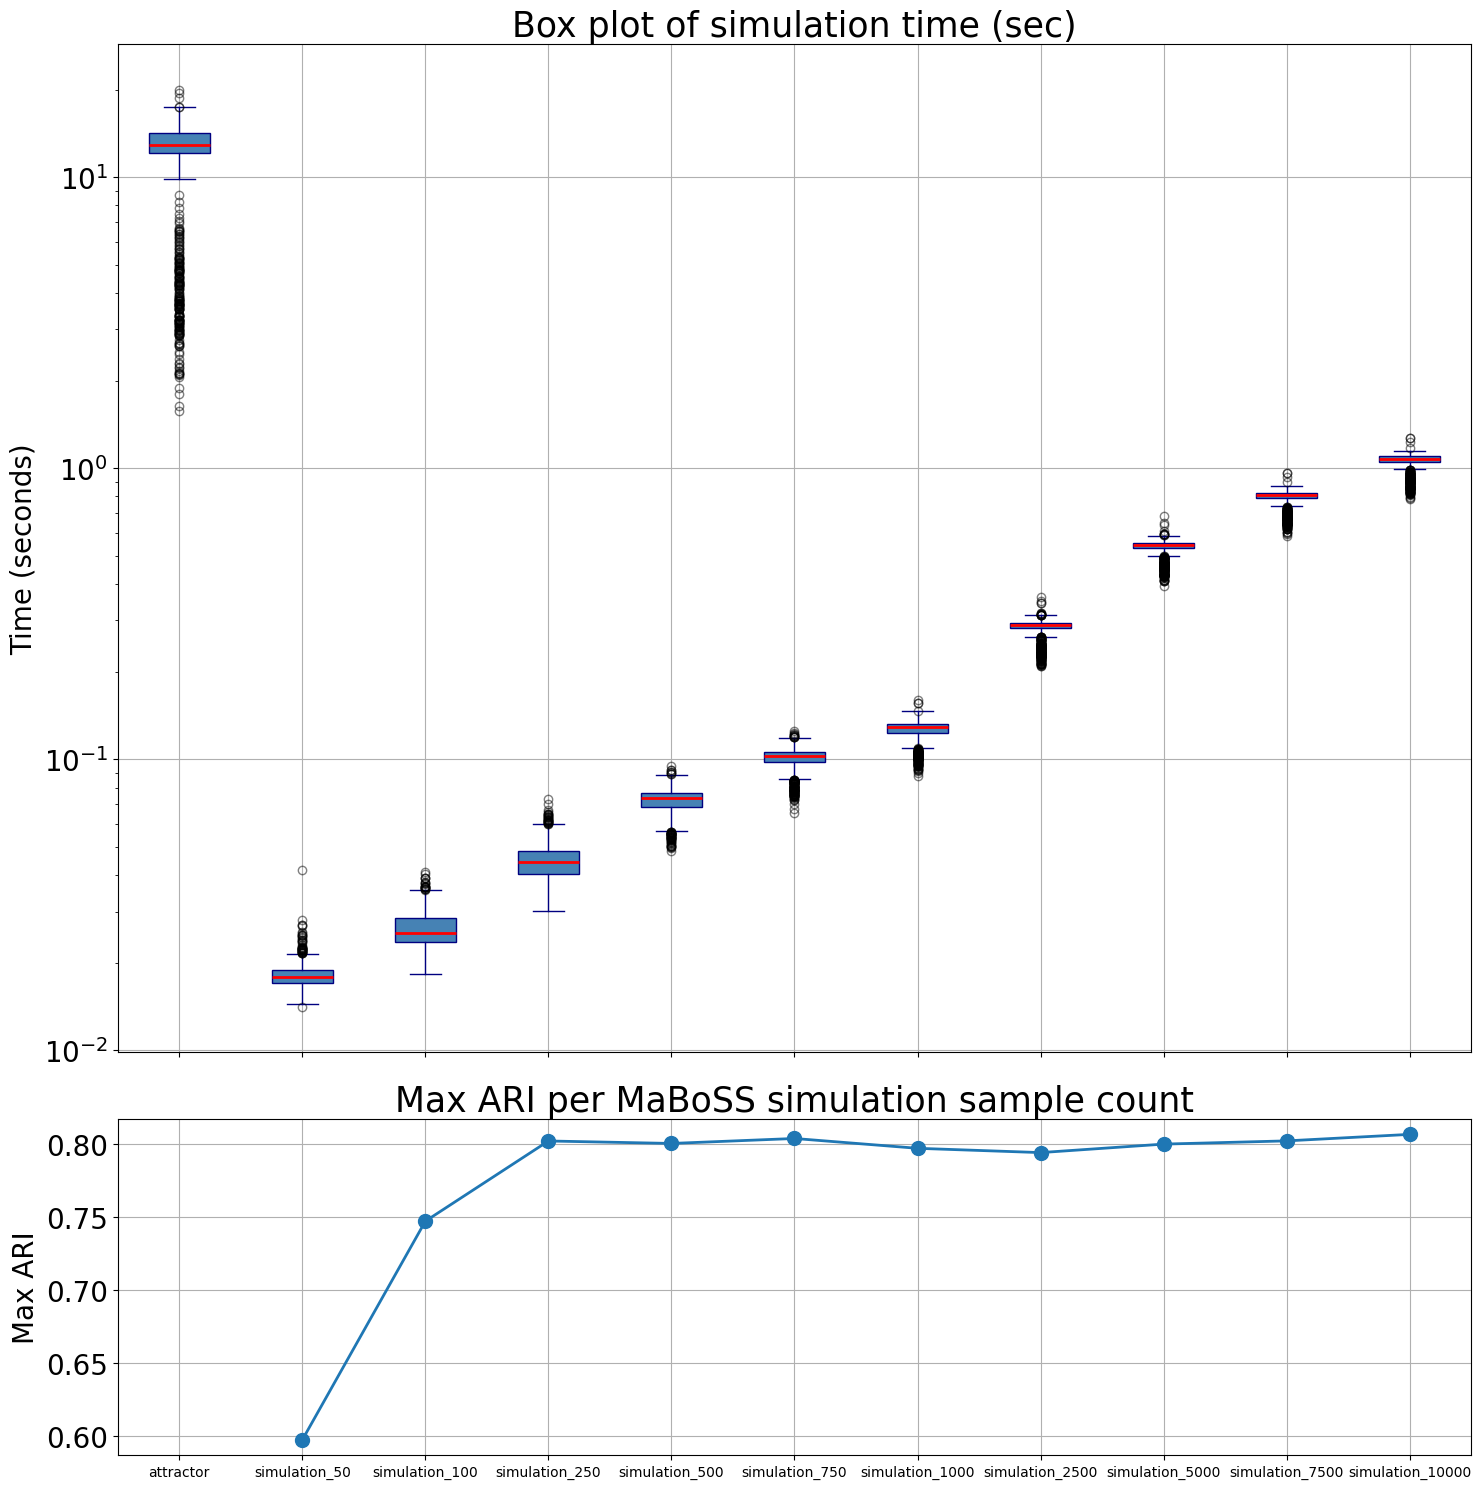

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 15), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Define x positions
x_positions = range(len(sorted_columns))

# Plot 1: Box plot per model
ax1.boxplot(
    [dfs[col].dropna() for col in sorted_columns],
    positions=list(x_positions),
    tick_labels=sorted_columns,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='navy'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    flierprops=dict(marker='o', color='gray', alpha=0.5)
)
ax1.set_yscale('log')
ax1.set_ylabel('Time (seconds)', fontsize=20)
ax1.set_title('Box plot of simulation time (sec)', fontsize=25)
ax1.tick_params(axis='y', labelsize=20)
ax1.grid()

# Plot 2: Maximum ARI per model (all trajectories)
ax2.plot(x_positions, alltraj.reindex(sorted_columns).values,
         marker='o', markersize=10, linewidth=2)
ax2.set_xlabel(None)
ax2.set_ylabel('Max ARI', fontsize=20)
ax2.set_title('Max ARI per MaBoSS simulation sample count', fontsize=25)
ax2.tick_params(axis='y', labelsize=20)
ax2.grid()

plt.tight_layout()
plt.show()


In [8]:
test = dfs.mean(axis = 0)
test['attractor']/test['simulation_1000']

np.float64(93.40054981798535)